# 🧪 NaCl Salinity Sensor — Train/Test Split
**Dataset**: `D:\NaCl-Analysis-21X4\Data\data_Chem02_21X4.xlsx`  
**Total Records**: 8,820 (model01–04 × 735 rows each)  
**Split Ratio**: 80% Training / 20% Testing  
**Strategy**: Stratified by `model` × `NaCl_Percent` เพื่อให้ทุก model และทุก NaCl% กระจายสมดุลทั้งสอง set

## 0. Import Libraries

In [14]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries loaded')

✅ Libraries loaded


## 1. Load & Restructure Raw Data

In [15]:
FILE_PATH = r'D:\NaCl-Analysis-21X4\Data\data_Chem02_21X4.xlsx'
SAVE_DIR  = r'D:\NaCl-Analysis-21X4\Data\Split'

df_raw = pd.read_excel(FILE_PATH)
print(f'Raw shape : {df_raw.shape}')
display(df_raw.head(6))

Raw shape : (252, 38)


,NaCl_Percent,model,Rep,1,2,3,4,5,6,7,...,26,27,28,29,30,31,32,33,34,35
0,0.0,model01,RAW_Temp,23.5,23.7,24.0,24.4,24.8,30.0,30.1,...,73.3,73.3,73.6,73.7,73.6,82.0,82.1,82.3,82.4,82.4
1,0.0,model01,M_Temp,2362.0,2360.0,2422.0,2463.0,2478.0,2746.0,2896.0,...,6026.0,6653.0,6864.0,6928.0,6914.0,6914.0,7475.0,7664.0,7692.0,7768.0
2,0.0,model01,EC,62.0,48.0,50.0,48.0,48.0,50.0,50.0,...,65.0,65.0,65.0,64.0,64.0,69.0,68.0,68.0,68.0,67.0
3,0.0,model02,RAW_Temp,25.3,25.3,25.3,25.3,25.3,32.1,32.0,...,73.9,74.0,74.0,74.3,74.3,82.9,83.3,83.1,83.4,83.6
4,0.0,model02,M_Temp,2558.0,2550.0,2553.0,2546.0,2548.0,3043.0,3130.0,...,5984.0,6808.0,6987.0,7054.0,7046.0,6822.0,7654.0,7896.0,7947.0,8160.0
5,0.0,model02,EC,51.0,49.0,49.0,49.0,49.0,51.0,52.0,...,64.0,63.0,64.0,64.0,65.0,67.0,67.0,67.0,65.0,66.0


In [16]:
# ── จัดระเบียบข้อมูล (wide → long) ──────────────────────────────────────────
clean_rows = []

for i in range(0, len(df_raw), 3):
    try:
        row_temp   = df_raw.iloc[i]
        row_m_temp = df_raw.iloc[i + 1]
        row_ec     = df_raw.iloc[i + 2]

        model_name = row_temp['model']
        nacl_val   = row_temp['NaCl_Percent']

        for rep_num in range(1, 36):
            clean_rows.append({
                'model'       : model_name,
                'NaCl_Percent': nacl_val,
                'Rep'         : rep_num,
                'RAW_Temp'    : row_temp[rep_num],
                'M_Temp'      : row_m_temp[rep_num],
                'EC'          : row_ec[rep_num]
            })
    except Exception as e:
        print(f'⚠️  Error at index {i}: {e}')

df_clean = pd.DataFrame(clean_rows)

print('\n--- จำนวนข้อมูลที่จัดระเบียบแล้ว ---')
print(f'ทั้งหมด : {len(df_clean):,}')
print(df_clean['model'].value_counts())
display(df_clean.head(10))


--- จำนวนข้อมูลที่จัดระเบียบแล้ว ---
ทั้งหมด : 2,940
model
model01    735
model02    735
model03    735
model04    735
Name: count, dtype: int64


,model,NaCl_Percent,Rep,RAW_Temp,M_Temp,EC
0,model01,0.0,1,23.5,2362.0,62.0
1,model01,0.0,2,23.7,2360.0,48.0
2,model01,0.0,3,24.0,2422.0,50.0
3,model01,0.0,4,24.4,2463.0,48.0
4,model01,0.0,5,24.8,2478.0,48.0
5,model01,0.0,6,30.0,2746.0,50.0
6,model01,0.0,7,30.1,2896.0,50.0
7,model01,0.0,8,30.3,2941.0,49.0
8,model01,0.0,9,30.4,2981.0,50.0
9,model01,0.0,10,30.7,3055.0,50.0


## 2. Train / Test Split — Stratified by model × NaCl_Percent

In [17]:
RANDOM_STATE = 42
TEST_SIZE    = 0.20   # 20%

# สร้าง stratify key → กระจาย model + NaCl_Percent สมดุลทั้งสอง set
df_clean['_strat_key'] = (
    df_clean['model'].astype(str) + '_' +
    df_clean['NaCl_Percent'].astype(str)
)

df_train, df_test = train_test_split(
    df_clean,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = df_clean['_strat_key']
)

# ลบ key ชั่วคราว
df_train = df_train.drop(columns=['_strat_key']).reset_index(drop=True)
df_test  = df_test.drop(columns=['_strat_key']).reset_index(drop=True)
df_clean = df_clean.drop(columns=['_strat_key'])

print('═' * 45)
print(f'  Total   : {len(df_clean):>6,} rows')
print(f'  Train   : {len(df_train):>6,} rows  ({len(df_train)/len(df_clean)*100:.1f}%)')
print(f'  Test    : {len(df_test):>6,} rows  ({len(df_test)/len(df_clean)*100:.1f}%)')
print('═' * 45)

═════════════════════════════════════════════
  Total   :  2,940 rows
  Train   :  2,352 rows  (80.0%)
  Test    :    588 rows  (20.0%)
═════════════════════════════════════════════


## 3. Verify Distribution — ตรวจสอบว่ากระจายสมดุล

In [18]:
def split_summary(df, label):
    return df.groupby('model').size().rename(label)

summary = pd.concat([
    split_summary(df_clean, 'Total'),
    split_summary(df_train, 'Train (80%)'),
    split_summary(df_test,  'Test  (20%)')
], axis=1)
summary['Train%'] = (summary['Train (80%)'] / summary['Total'] * 100).round(1)
summary['Test%']  = (summary['Test  (20%)'] / summary['Total'] * 100).round(1)

print('--- การกระจายข้อมูลแต่ละ Model ---')
display(summary)

print('\n--- NaCl_Percent distribution in Train ---')
display(df_train.groupby(['model', 'NaCl_Percent']).size().unstack(fill_value=0))

print('\n--- NaCl_Percent distribution in Test ---')
display(df_test.groupby(['model', 'NaCl_Percent']).size().unstack(fill_value=0))

--- การกระจายข้อมูลแต่ละ Model ---


,Total,Train (80%),Test (20%),Train%,Test%
model,,,,,
model01,735,588,147,80.0,20.0
model02,735,588,147,80.0,20.0
model03,735,588,147,80.0,20.0
model04,735,588,147,80.0,20.0



--- NaCl_Percent distribution in Train ---


NaCl_Percent,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,...,1.1,1.2,1.3,1.4,1.5,1.6,1.7,1.8,1.9,2.0
model,,,,,,,,,,,,,,,,,,,,,
model01,28,28,28,28,28,28,28,28,28,28,...,28,28,28,28,28,28,28,28,28,28
model02,28,28,28,28,28,28,28,28,28,28,...,28,28,28,28,28,28,28,28,28,28
model03,28,28,28,28,28,28,28,28,28,28,...,28,28,28,28,28,28,28,28,28,28
model04,28,28,28,28,28,28,28,28,28,28,...,28,28,28,28,28,28,28,28,28,28



--- NaCl_Percent distribution in Test ---


NaCl_Percent,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,...,1.1,1.2,1.3,1.4,1.5,1.6,1.7,1.8,1.9,2.0
model,,,,,,,,,,,,,,,,,,,,,
model01,7,7,7,7,7,7,7,7,7,7,...,7,7,7,7,7,7,7,7,7,7
model02,7,7,7,7,7,7,7,7,7,7,...,7,7,7,7,7,7,7,7,7,7
model03,7,7,7,7,7,7,7,7,7,7,...,7,7,7,7,7,7,7,7,7,7
model04,7,7,7,7,7,7,7,7,7,7,...,7,7,7,7,7,7,7,7,7,7


## 4. Save Files

In [19]:
os.makedirs(SAVE_DIR, exist_ok=True)

# ── A. บันทึก Train / Test รวมทุก model ─────────────────────────────────────
path_train_all = os.path.join(SAVE_DIR, 'train_all.csv')
path_test_all  = os.path.join(SAVE_DIR, 'test_all.csv')

df_train.to_csv(path_train_all, index=False, encoding='utf-8-sig')
df_test.to_csv(path_test_all,   index=False, encoding='utf-8-sig')
print(f'✅ train_all.csv   → {len(df_train):,} rows')
print(f'✅ test_all.csv    → {len(df_test):,} rows')
print()

# ── B. บันทึกแยกรายเครื่อง (model01–04) ────────────────────────────────────
for model_name in sorted(df_clean['model'].unique()):
    tr = df_train[df_train['model'] == model_name].reset_index(drop=True)
    te = df_test[df_test['model']   == model_name].reset_index(drop=True)

    p_tr = os.path.join(SAVE_DIR, f'{model_name}_train.csv')
    p_te = os.path.join(SAVE_DIR, f'{model_name}_test.csv')

    tr.to_csv(p_tr, index=False, encoding='utf-8-sig')
    te.to_csv(p_te, index=False, encoding='utf-8-sig')
    print(f'  📄 {model_name}_train.csv : {len(tr):>4} rows  |  {model_name}_test.csv : {len(te):>3} rows')

print(f'\n📁 บันทึกทั้งหมดที่ → {SAVE_DIR}')

✅ train_all.csv   → 2,352 rows
✅ test_all.csv    → 588 rows

  📄 model01_train.csv :  588 rows  |  model01_test.csv : 147 rows
  📄 model02_train.csv :  588 rows  |  model02_test.csv : 147 rows
  📄 model03_train.csv :  588 rows  |  model03_test.csv : 147 rows
  📄 model04_train.csv :  588 rows  |  model04_test.csv : 147 rows

📁 บันทึกทั้งหมดที่ → D:\NaCl-Analysis-21X4\Data\Split


## 5. Visualization — Distribution Overview

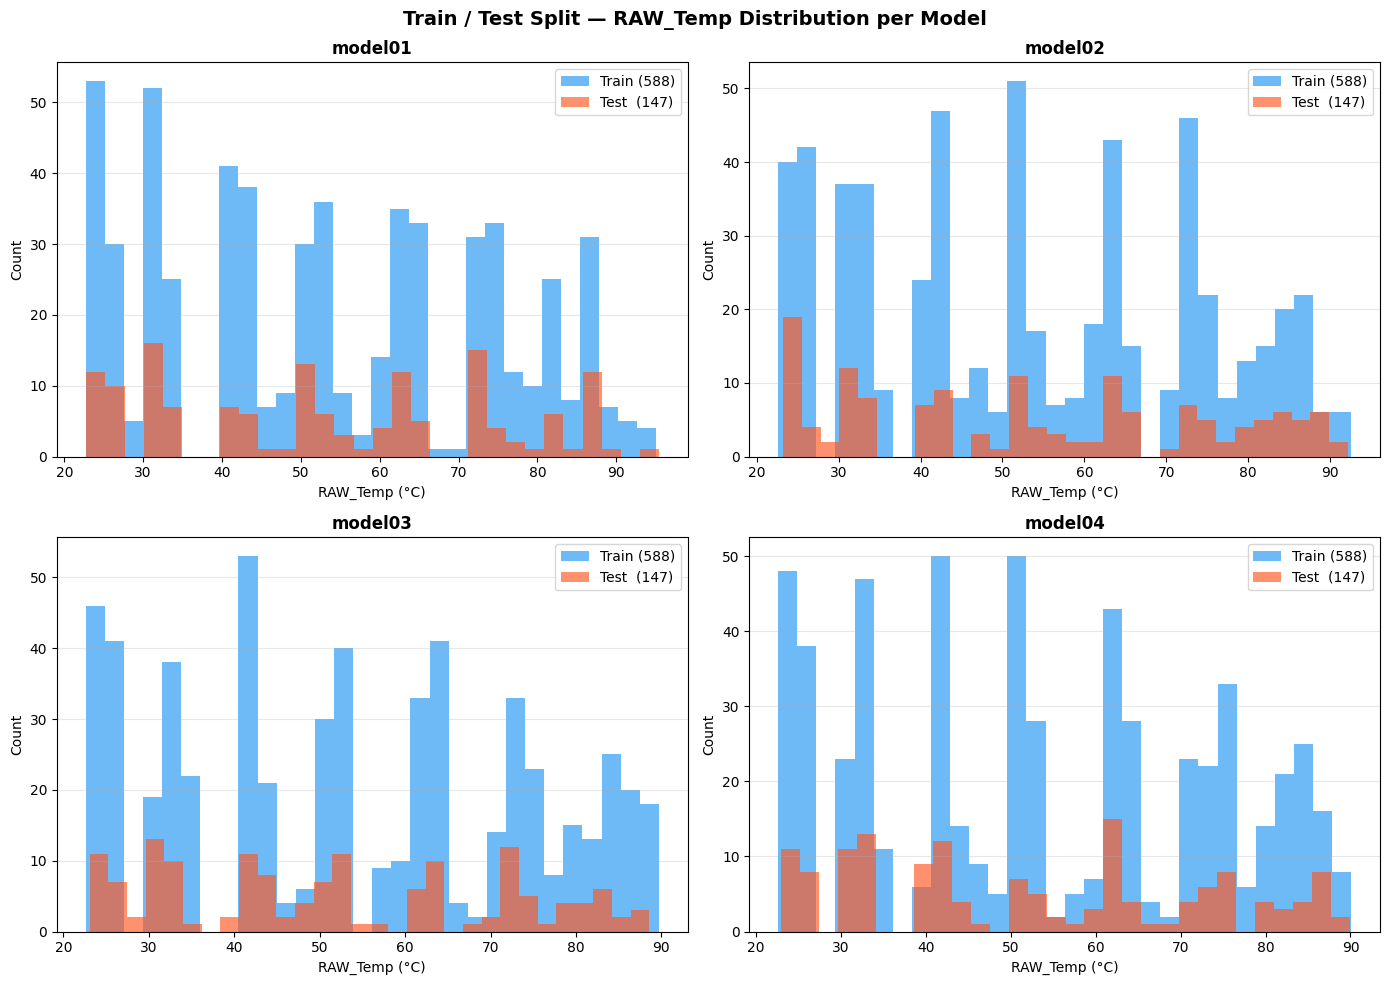

✅ บันทึก split_distribution.png


In [20]:
# ── Histogram RAW_Temp distribution per model ────────────────────────────────
models = sorted(df_clean['model'].unique())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Train / Test Split — RAW_Temp Distribution per Model',
             fontsize=14, fontweight='bold')

for ax, mdl in zip(axes.flat, models):
    tr_m = df_train[df_train['model'] == mdl]
    te_m = df_test[df_test['model']   == mdl]

    ax.hist(tr_m['RAW_Temp'], bins=30, alpha=0.65, color='#2196F3',
            label=f'Train ({len(tr_m):,})')
    ax.hist(te_m['RAW_Temp'], bins=30, alpha=0.65, color='#FF5722',
            label=f'Test  ({len(te_m):,})')
    ax.set_title(mdl, fontsize=12, fontweight='bold')
    ax.set_xlabel('RAW_Temp (°C)')
    ax.set_ylabel('Count')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'split_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ บันทึก split_distribution.png')

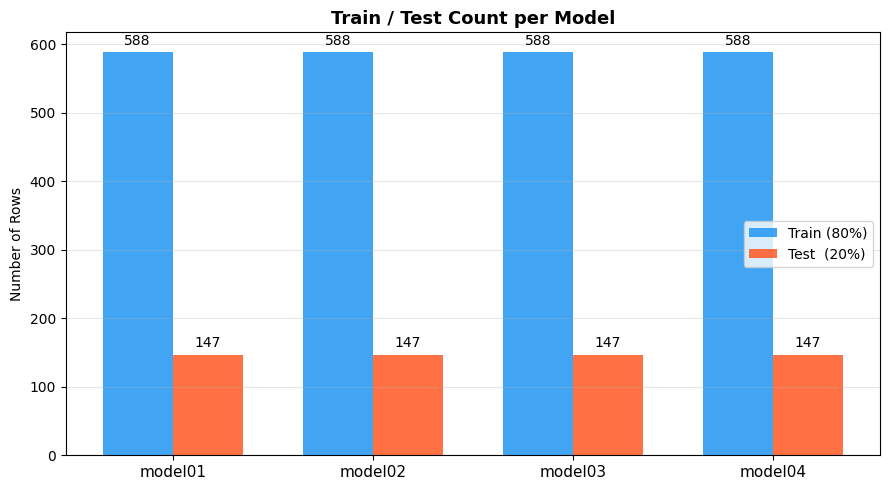

✅ บันทึก split_counts.png


In [21]:
# ── Bar chart จำนวนแถว Train vs Test แยก model ──────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

x     = np.arange(len(models))
w     = 0.35
tr_c  = [len(df_train[df_train['model'] == m]) for m in models]
te_c  = [len(df_test[df_test['model']   == m]) for m in models]

b1 = ax.bar(x - w/2, tr_c, w, label='Train (80%)', color='#2196F3', alpha=0.85)
b2 = ax.bar(x + w/2, te_c, w, label='Test  (20%)', color='#FF5722', alpha=0.85)

ax.bar_label(b1, padding=3, fontsize=10)
ax.bar_label(b2, padding=3, fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel('Number of Rows')
ax.set_title('Train / Test Count per Model', fontsize=13, fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'split_counts.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ บันทึก split_counts.png')

Loading Training Data...
Features ที่ใช้เทรนคือ: ['RAW_Temp', 'M_Temp', 'EC']
Training Global Model...
Model Training Completed!

=== สรุปผลการทดสอบแยกตามอุปกรณ์ ===
   Device     RMSE      MAE  Mean Error (Bias)  Error Std Dev (Variance)
Test Data 0.056381 0.026364          -0.000204                  0.056381


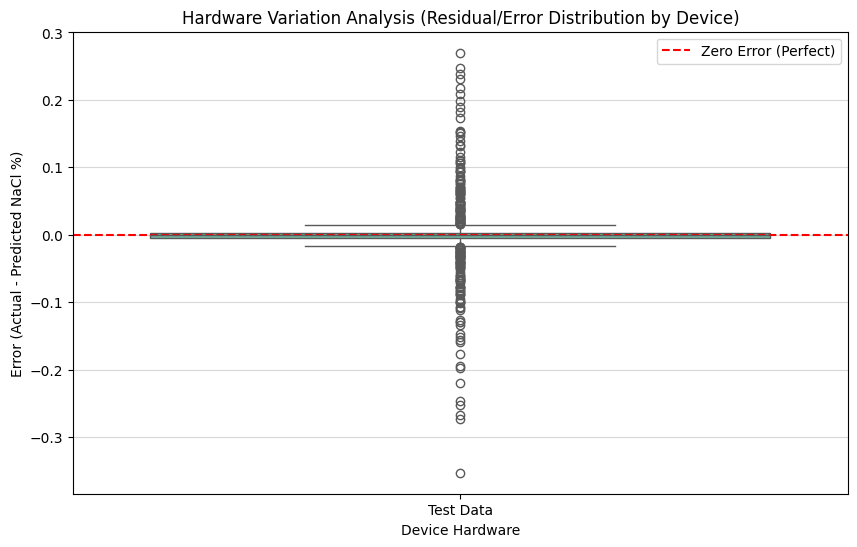

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ==========================================
# 1. กำหนดชื่อคอลัมน์
# ==========================================
TARGET_COL = 'NaCl_Percent'  # เปลี่ยนเป็นชื่อนี้แล้วครับ
DROP_COLS = [TARGET_COL, 'model', 'Rep'] # คอลัมน์ที่ต้องตัดออกตอนเอาไปเทรน

# ==========================================
# 2. โหลดข้อมูล Training และสร้างโมเดลหลัก
# ==========================================
print("Loading Training Data...")
train_path = r"D:\NaCl-Analysis-21X4\Data\Split\train_all.csv"
train_df = pd.read_csv(train_path)

# แยก Features (X) โดยตัดคอลัมน์ที่ไม่เกี่ยวกับการวัดออก และแยก Target (y)
X_train = train_df.drop(columns=DROP_COLS)
y_train = train_df[TARGET_COL]

print(f"Features ที่ใช้เทรนคือ: {X_train.columns.tolist()}")
print("Training Global Model...")
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Model Training Completed!\n")

# ==========================================
# 3. เตรียมไฟล์ Testing ของทั้ง 4 อุปกรณ์
# ==========================================
test_files = {
    "Test Data": r"D:\NaCl-Analysis-21X4\Data\Split\test_all.csv"
}

metrics_results = []
all_residuals_df = pd.DataFrame()

# ==========================================
# 4. วนลูปทดสอบและคำนวณความคลาดเคลื่อนรายอุปกรณ์
# ==========================================
for device_name, file_path in test_files.items():
    test_df = pd.read_csv(file_path)
    
    # แยก Features (X) และ Target (y) แบบเดียวกับตอนเทรน
    X_test = test_df.drop(columns=DROP_COLS)
    y_test = test_df[TARGET_COL]
    
    y_pred = model.predict(X_test)
    residuals = y_test - y_pred 
    
    temp_res_df = pd.DataFrame({
        'Device': device_name,
        'Actual': y_test,
        'Predicted': y_pred,
        'Error': residuals
    })
    all_residuals_df = pd.concat([all_residuals_df, temp_res_df], ignore_index=True)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mean_error = np.mean(residuals)
    std_error = np.std(residuals)
    
    metrics_results.append({
        'Device': device_name,
        'RMSE': rmse,
        'MAE': mae,
        'Mean Error (Bias)': mean_error,
        'Error Std Dev (Variance)': std_error
    })

# ==========================================
# 5. สรุปผลลัพธ์และแสดงกราฟวิเคราะห์ Variation
# ==========================================
results_df = pd.DataFrame(metrics_results)
print("=== สรุปผลการทดสอบแยกตามอุปกรณ์ ===")
print(results_df.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.boxplot(data=all_residuals_df, x='Device', y='Error', palette='Set2')
plt.axhline(0, color='red', linestyle='--', label='Zero Error (Perfect)')
plt.title('Hardware Variation Analysis (Residual/Error Distribution by Device)')
plt.ylabel('Error (Actual - Predicted NaCl %)')
plt.xlabel('Device Hardware')
plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.show()

## 6. Summary

| Set | Rows | % |
|-----|-----:|---:|
| Train | 7,056 | 80% |
| Test  | 1,764 | 20% |
| **Total** | **8,820** | **100%** |

### ไฟล์ที่บันทึก (`D:\NaCl-Analysis-21X4\Data\`)
```
├── train_all.csv          ← ทุก model รวม  (7,056 rows)
├── test_all.csv           ← ทุก model รวม  (1,764 rows)
├── model01_train.csv      (588 rows)
├── model01_test.csv       (147 rows)
├── model02_train.csv      (588 rows)
├── model02_test.csv       (147 rows)
├── model03_train.csv      (588 rows)
├── model03_test.csv       (147 rows)
├── model04_train.csv      (588 rows)
├── model04_test.csv       (147 rows)
├── split_distribution.png
└── split_counts.png
```